In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import albumentations as Albu
from PIL import Image
import os
from typing import List, Tuple
import random

from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [21]:
# Paths
ROOT_DIR = '../../../..'
data_dir = '../../../../../dataset'
images_dir = os.path.join(data_dir, 'tiles')
model_path = '../models/b0-entropy.pth'

# Model parameters
output_classes = 5
batch_size = 1  # Use batch_size=1 for GradCAM
num_workers = 2

## 3. GradCAM Implementation

In [22]:
class GradCAM:
    """GradCAM implementation for visualizing model attention."""
    
    def __init__(self, model, target_layer):
        """
        Args:
            model: The neural network model
            target_layer: The layer to compute GradCAM on (usually last conv layer)
        """
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        """Hook to save forward pass activations."""
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        """Hook to save backward pass gradients."""
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor, target_class=None):
        """
        Generate GradCAM heatmap for a given input.
        
        Args:
            input_tensor: Input image tensor (1, C, H, W)
            target_class: Target class index. If None, uses predicted class.
        
        Returns:
            cam: GradCAM heatmap
            prediction: Model prediction
            probs: Class probabilities
        """
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)
        probs = torch.sigmoid(output)
        
        # Get prediction (sum of probabilities, rounded)
        prediction = probs.sum(1).detach().round()
        
        # If target_class is None, use the predicted class
        if target_class is None:
            target_class = int(prediction.item())
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for target class
        # For ordinal classification, we use the cumulative probability at target_class
        if target_class < output.shape[1]:
            class_output = output[0, target_class]
        else:
            class_output = output.sum()
        
        class_output.backward()
        
        # Generate CAM
        gradients = self.gradients  # (1, C, H, W)
        activations = self.activations  # (1, C, H, W)
        
        # Global average pooling of gradients
        weights = gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        
        # Weighted sum of activations
        cam = (weights * activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        
        # Apply ReLU and normalize
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()  # (H, W)
        
        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam, prediction.item(), probs.cpu().detach().numpy()[0]
    
    def generate_cam_with_entropy(self, input_tensor, target_class=None):
        """
        Generate GradCAM heatmap along with entropy score.
        
        Args:
            input_tensor: Input image tensor (1, C, H, W)
            target_class: Target class index. If None, uses predicted class.
        
        Returns:
            cam: GradCAM heatmap
            prediction: Model prediction
            probs: Class probabilities
            entropy: Prediction entropy
        """
        cam, prediction, probs = self.generate_cam(input_tensor, target_class)
        
        # Calculate entropy
        probs_tensor = torch.tensor(probs).unsqueeze(0)
        entropy = calculate_entropy(predictions=probs_tensor).item()
        
        return cam, prediction, probs, entropy

## 4. Visualization Functions

In [23]:
def apply_colormap_on_image(org_img, activation_map, colormap=cv2.COLORMAP_JET, alpha=0.5):
    """
    Apply colormap on activation map and overlay on original image.
    
    Args:
        org_img: Original image (H, W, 3) in RGB format, values in [0, 255]
        activation_map: Activation heatmap (H, W), values in [0, 1]
        colormap: OpenCV colormap
        alpha: Blending factor
    
    Returns:
        Blended image with heatmap overlay
    """
    # Resize activation map to match image size
    activation_map = cv2.resize(activation_map, (org_img.shape[1], org_img.shape[0]))
    
    # Convert to uint8
    heatmap = np.uint8(255 * activation_map)
    
    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, colormap)
    
    # Convert BGR to RGB (OpenCV uses BGR)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Ensure org_img is uint8
    if org_img.dtype != np.uint8:
        org_img = np.uint8(org_img)
    
    # Blend images
    superimposed_img = heatmap * alpha + org_img * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)
    
    return superimposed_img, heatmap


def visualize_gradcam(image, cam, prediction, true_label, probs, entropy, image_id, 
                      class_names=None, save_path=None):
    """
    Visualize GradCAM results with entropy information.
    
    Args:
        image: Original image (H, W, 3) in RGB
        cam: GradCAM heatmap
        prediction: Predicted class
        true_label: Ground truth label
        probs: Class probabilities
        entropy: Prediction entropy
        image_id: Image identifier
        class_names: List of class names
        save_path: Path to save the visualization
    """
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(probs))]
    
    # Create overlay
    overlay, heatmap = apply_colormap_on_image(image, cam)
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # GradCAM heatmap
    axes[1].imshow(heatmap)
    axes[1].set_title('GradCAM Heatmap', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(overlay)
    axes[2].set_title('GradCAM Overlay', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Add prediction information
    correct = '✓' if prediction == true_label else '✗'
    title = f'Image: {image_id}\n'
    title += f'Prediction: {int(prediction)} | True: {int(true_label)} {correct}\n'
    title += f'Entropy: {entropy:.4f} | Probs: {probs}'
    
    fig.suptitle(title, fontsize=12, y=0.98)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


def visualize_gradcam_grid(images_data, nrows=2, ncols=3, save_path=None):
    """
    Visualize multiple GradCAM results in a grid.
    
    Args:
        images_data: List of tuples (image, cam, prediction, true_label, entropy, image_id)
        nrows: Number of rows in grid
        ncols: Number of columns in grid
        save_path: Path to save the visualization
    """
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    
    for idx, (image, cam, pred, true_label, entropy, img_id) in enumerate(images_data[:nrows * ncols]):
        overlay, _ = apply_colormap_on_image(image, cam)
        
        axes[idx].imshow(overlay)
        correct = '✓' if pred == true_label else '✗'
        title = f'{img_id}\nPred: {int(pred)} | True: {int(true_label)} {correct}\nEntropy: {entropy:.3f}'
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(images_data), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

## 5. Load Model and Data

In [24]:
# Load model
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=0.6)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [25]:
# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")
print(f"Test set: {len(df_test)} samples")

# Load entropy scores if available
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"Entropy data: {len(df_entropy)} samples")

Test set: 1592 samples
Entropy data: 903 samples


In [26]:
# Create dataset (no augmentation for visualization)
test_transforms = Albu.Compose([])
test_dataset = PandasDataset(images_dir, df_test, transforms=test_transforms)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

## 6. Initialize GradCAM

We target the last convolutional layer of EfficientNet B0 for GradCAM visualization.

In [27]:
# Get the target layer (last conv layer in EfficientNet features)
target_layer = model.model.features[-1]

print(f"Target layer: {target_layer}")

# Initialize GradCAM
gradcam = GradCAM(model, target_layer)

Target layer: Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)


## 7. Generate GradCAM Visualizations

### 7.1 Single Image Example

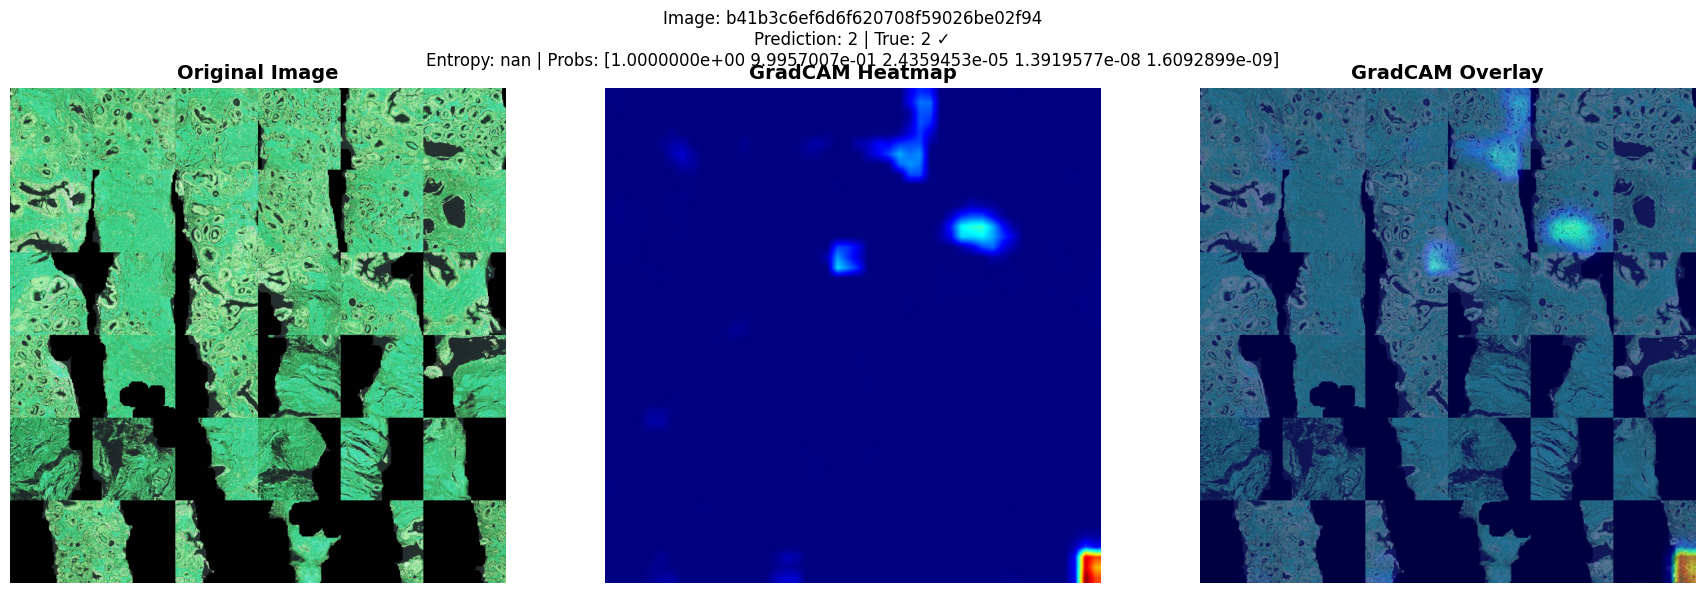

In [28]:
# Select a random sample
sample_idx = random.randint(0, len(test_dataset) - 1)
image_tensor, label_tensor, image_id = test_dataset[sample_idx]

# Convert label from one-hot to class index
true_label = label_tensor.sum().item()

# Add batch dimension
input_tensor = image_tensor.unsqueeze(0).to(device)

# Generate GradCAM
cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)

# Convert image tensor to numpy for visualization
image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
image_np = (image_np * 255).astype(np.uint8)  # Assuming image is normalized to [0, 1]

# Visualize
visualize_gradcam(
    image_np, cam, prediction, true_label, probs, entropy, image_id,
    save_path=f'gradcam_single_{image_id}.png'
)

### 7.2 Multiple Images with Different Entropy Levels

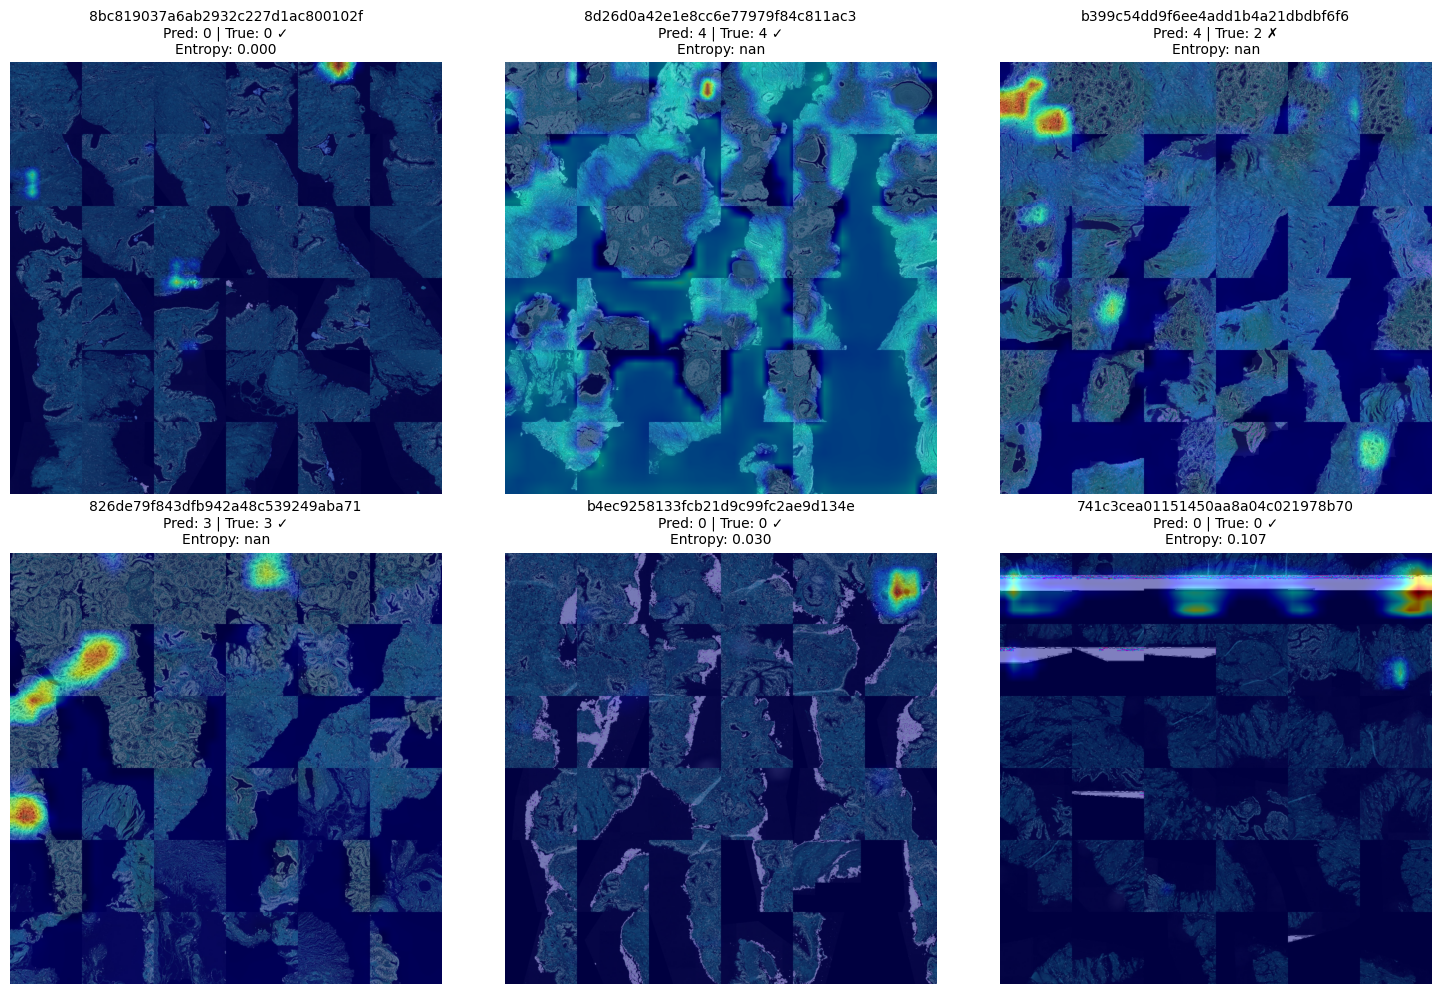

In [41]:
# Create output directory
os.makedirs('', exist_ok=True)

# Generate GradCAM for multiple samples
num_samples = 6
sample_indices = random.sample(range(len(test_dataset)), num_samples)

images_data = []

for idx in sample_indices:
    image_tensor, label_tensor, image_id = test_dataset[idx]
    true_label = label_tensor.sum().item()
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)
    
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8)
    
    images_data.append((image_np, cam, prediction, true_label, entropy, image_id))

# Visualize in grid
visualize_gradcam_grid(
    images_data,
    nrows=2,
    ncols=3,
    save_path='gradcam_grid2.png'
)

### 7.3 Analyze High vs Low Entropy Predictions

In [31]:
# Compute entropy for all test samples
all_entropies = []
all_predictions = []
all_true_labels = []
all_image_ids = []

print("Computing entropy for all test samples...")

with torch.no_grad():
    for image_tensor, label_tensor, image_id in test_dataset:
        input_tensor = image_tensor.unsqueeze(0).to(device)
        output = model(input_tensor)
        probs = torch.sigmoid(output)
        
        prediction = probs.sum(1).detach().round().item()
        true_label = label_tensor.sum().item()
        entropy = calculate_entropy(predictions=probs).item()
        
        all_entropies.append(entropy)
        all_predictions.append(prediction)
        all_true_labels.append(true_label)
        all_image_ids.append(image_id)

# Create DataFrame with results
results_df = pd.DataFrame({
    'image_id': all_image_ids,
    'entropy': all_entropies,
    'prediction': all_predictions,
    'true_label': all_true_labels
})

results_df['correct'] = results_df['prediction'] == results_df['true_label']

print(f"\nEntropy statistics:")
print(results_df['entropy'].describe())
print(f"\nAccuracy: {results_df['correct'].mean():.4f}")

Computing entropy for all test samples...

Entropy statistics:
count    8.320000e+02
mean     5.401254e-02
std      8.863480e-02
min      4.475359e-07
25%      5.750511e-04
50%      7.331806e-03
75%      8.272746e-02
max      5.769897e-01
Name: entropy, dtype: float64

Accuracy: 0.6294


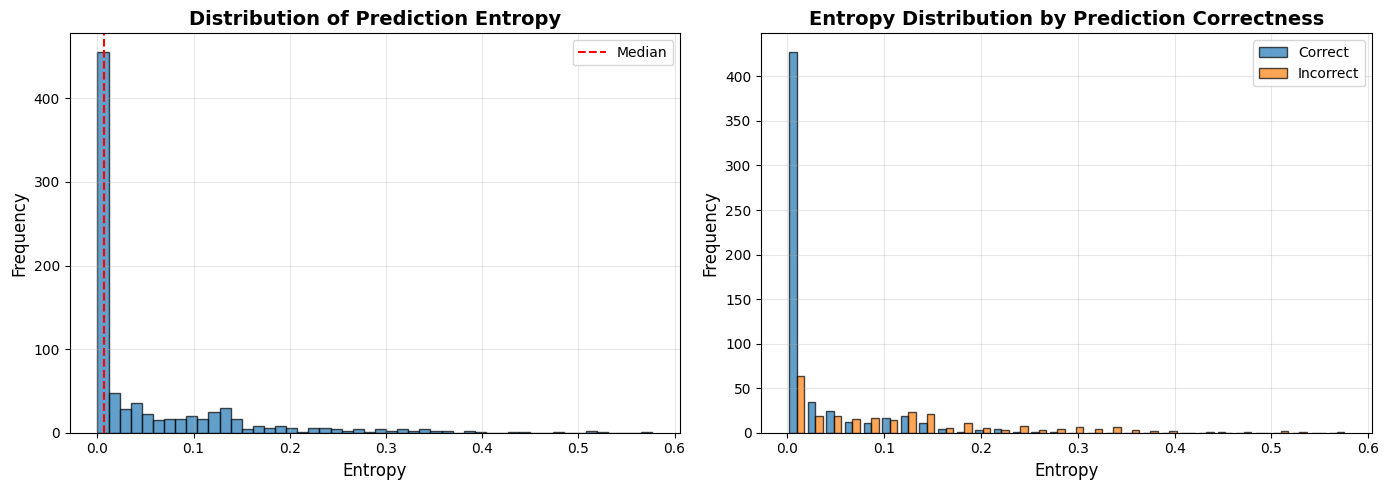

In [32]:
# Visualize entropy distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy histogram
axes[0].hist(results_df['entropy'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(results_df['entropy'].median(), color='red', linestyle='--', label='Median')
axes[0].set_xlabel('Entropy', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Prediction Entropy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Entropy vs Correctness
correct_entropies = results_df[results_df['correct']]['entropy']
incorrect_entropies = results_df[~results_df['correct']]['entropy']

axes[1].hist([correct_entropies, incorrect_entropies], bins=30, label=['Correct', 'Incorrect'],
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Entropy', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Entropy Distribution by Prediction Correctness', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('entropy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Select samples with highest and lowest entropy
results_df_sorted = results_df.sort_values('entropy')

# Low entropy samples (confident predictions)
low_entropy_samples = results_df_sorted.head(3)
# High entropy samples (uncertain predictions)
high_entropy_samples = results_df_sorted.tail(3)

print("Low entropy samples (confident):")
print(low_entropy_samples[['image_id', 'entropy', 'prediction', 'true_label', 'correct']])
print("\nHigh entropy samples (uncertain):")
print(high_entropy_samples[['image_id', 'entropy', 'prediction', 'true_label', 'correct']])

Low entropy samples (confident):
                             image_id       entropy  prediction  true_label  \
259  04c64f01e704712be3de4b5687f9bc9e  4.475359e-07         1.0         1.0   
161  e46178b5e2098fb3dafa4040c620ece4  1.714566e-06         1.0         1.0   
143  d2c92272a7d4464173a9488c6d0c41ed  3.221350e-06         0.0         0.0   

     correct  
259     True  
161     True  
143     True  

High entropy samples (uncertain):
                              image_id  entropy  prediction  true_label  \
1584  bbbe47a9dda0f30ae9d6457531b84ffa      NaN         3.0         4.0   
1587  cd9b8f5118bb6e5bf92edb4a5aed4455      NaN         5.0         4.0   
1588  9b8a5982b7e917e82a0b0ae84b922a55      NaN         1.0         1.0   

      correct  
1584    False  
1587    False  
1588     True  


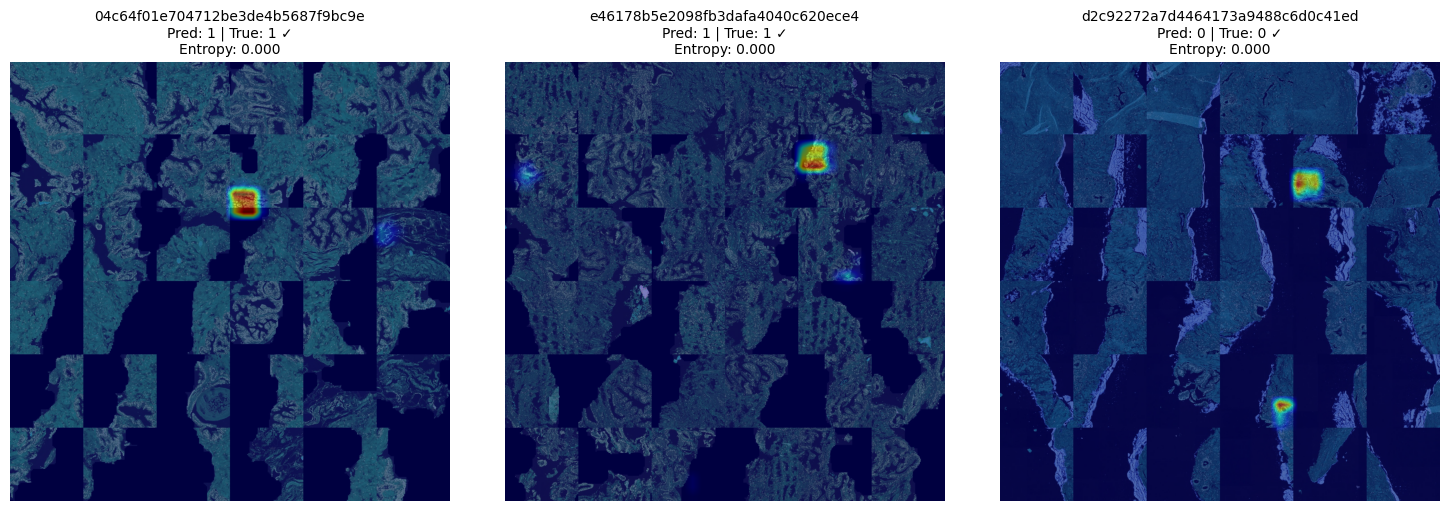

Low Entropy Samples (Confident Predictions)


In [34]:
# Visualize GradCAM for low entropy samples
low_entropy_data = []

for _, row in low_entropy_samples.iterrows():
    img_id = row['image_id']
    idx = all_image_ids.index(img_id)
    
    image_tensor, label_tensor, _ = test_dataset[idx]
    true_label = label_tensor.sum().item()
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)
    
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8)
    
    low_entropy_data.append((image_np, cam, prediction, true_label, entropy, img_id))

visualize_gradcam_grid(
    low_entropy_data,
    nrows=1,
    ncols=3,
    save_path='gradcam_low_entropy.png'
)
print("Low Entropy Samples (Confident Predictions)")

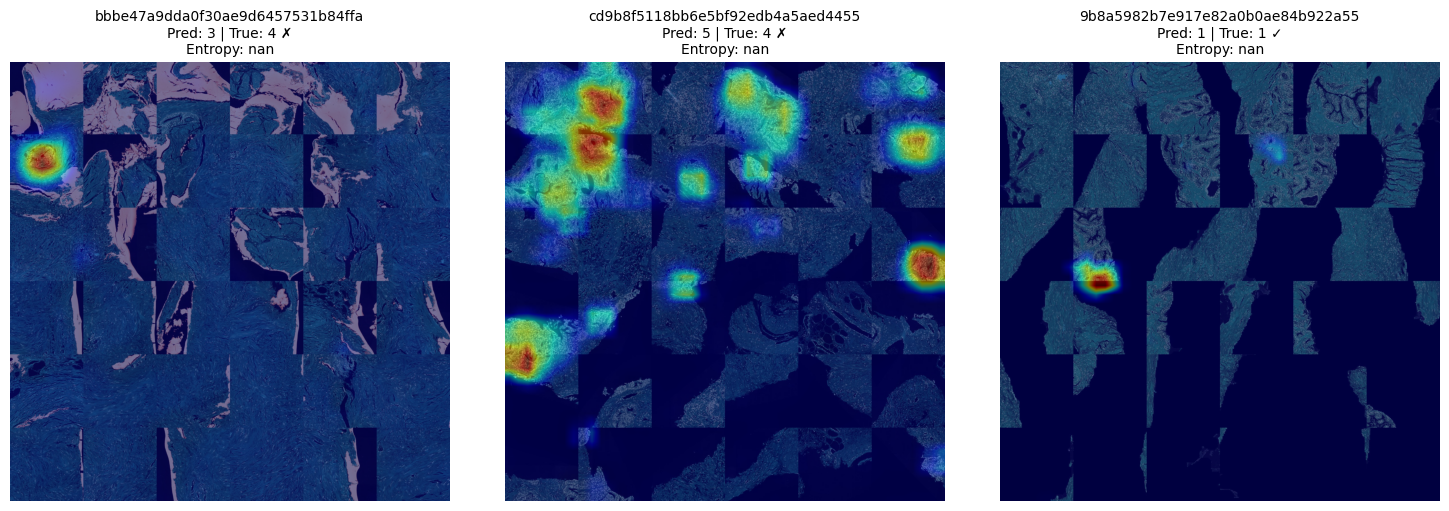

High Entropy Samples (Uncertain Predictions)


In [35]:
# Visualize GradCAM for high entropy samples
high_entropy_data = []

for _, row in high_entropy_samples.iterrows():
    img_id = row['image_id']
    idx = all_image_ids.index(img_id)
    
    image_tensor, label_tensor, _ = test_dataset[idx]
    true_label = label_tensor.sum().item()
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)
    
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8)
    
    high_entropy_data.append((image_np, cam, prediction, true_label, entropy, img_id))

visualize_gradcam_grid(
    high_entropy_data,
    nrows=1,
    ncols=3,
    save_path='gradcam_high_entropy.png'
)
print("High Entropy Samples (Uncertain Predictions)")

### 7.4 Analyze Correct vs Incorrect Predictions

In [36]:
# Select correct and incorrect predictions
correct_samples = results_df[results_df['correct']].sample(n=3, random_state=seed)
incorrect_samples = results_df[~results_df['correct']].sample(n=min(3, (~results_df['correct']).sum()), random_state=seed)

print("Correct predictions:")
print(correct_samples[['image_id', 'entropy', 'prediction', 'true_label']])
print("\nIncorrect predictions:")
print(incorrect_samples[['image_id', 'entropy', 'prediction', 'true_label']])

Correct predictions:
                              image_id   entropy  prediction  true_label
822   d9471d56985f343c8f300d622628ffaf       NaN         1.0         1.0
1186  7e33e3ef6468638fc307b42f5b78e98e  0.000062         0.0         0.0
1316  4d729d269ecb5ccfde006fc7ad498280       NaN         5.0         5.0

Incorrect predictions:
                              image_id  entropy  prediction  true_label
1400  501d3573cecce3ad9086a63df9794ebb      NaN         2.0         1.0
765   554970412cd2907b5a93ee5ec013965e      NaN         4.0         2.0
1380  775d39466b474d54ae714215034c5a83      NaN         4.0         3.0


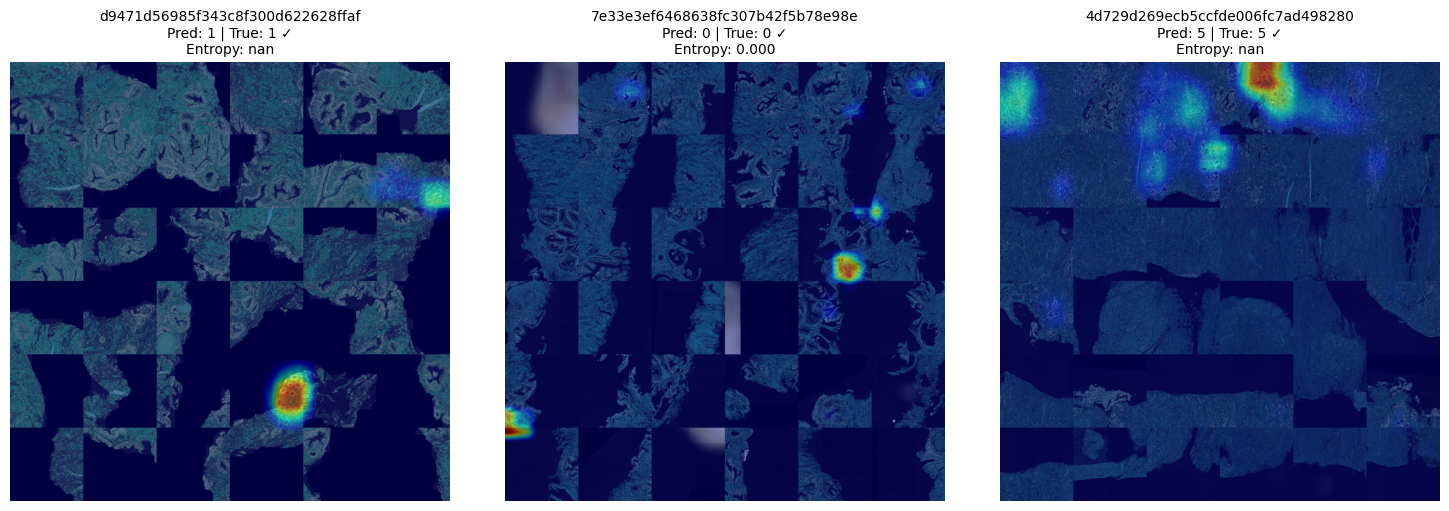

Correct Predictions


In [37]:
# Visualize GradCAM for correct predictions
correct_data = []

for _, row in correct_samples.iterrows():
    img_id = row['image_id']
    idx = all_image_ids.index(img_id)
    
    image_tensor, label_tensor, _ = test_dataset[idx]
    true_label = label_tensor.sum().item()
    
    input_tensor = image_tensor.unsqueeze(0).to(device)
    cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)
    
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    image_np = (image_np * 255).astype(np.uint8)
    
    correct_data.append((image_np, cam, prediction, true_label, entropy, img_id))

visualize_gradcam_grid(
    correct_data,
    nrows=1,
    ncols=3,
    save_path='gradcam_correct.png'
)
print("Correct Predictions")

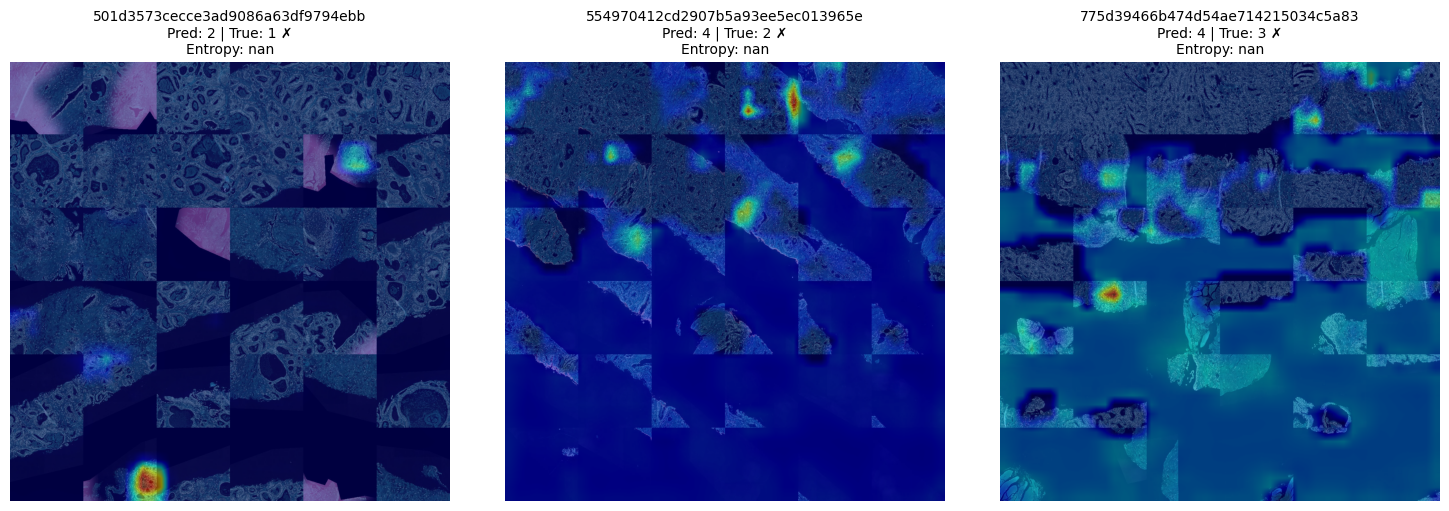

Incorrect Predictions


In [38]:
# Visualize GradCAM for incorrect predictions
if len(incorrect_samples) > 0:
    incorrect_data = []
    
    for _, row in incorrect_samples.iterrows():
        img_id = row['image_id']
        idx = all_image_ids.index(img_id)
        
        image_tensor, label_tensor, _ = test_dataset[idx]
        true_label = label_tensor.sum().item()
        
        input_tensor = image_tensor.unsqueeze(0).to(device)
        cam, prediction, probs, entropy = gradcam.generate_cam_with_entropy(input_tensor)
        
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        image_np = (image_np * 255).astype(np.uint8)
        
        incorrect_data.append((image_np, cam, prediction, true_label, entropy, img_id))
    
    visualize_gradcam_grid(
        incorrect_data,
        nrows=1,
        ncols=len(incorrect_data),
        save_path='gradcam_incorrect.png'
    )
    print("Incorrect Predictions")
else:
    print("No incorrect predictions found!")

## 8. Save Results

In [39]:
# Save entropy analysis results
results_df.to_csv('gradcam_entropy_results.csv', index=False)
print("Results saved to gradcam_entropy_results.csv")

# Summary statistics
summary = {
    'total_samples': len(results_df),
    'accuracy': results_df['correct'].mean(),
    'mean_entropy': results_df['entropy'].mean(),
    'std_entropy': results_df['entropy'].std(),
    'median_entropy': results_df['entropy'].median(),
    'mean_entropy_correct': results_df[results_df['correct']]['entropy'].mean(),
    'mean_entropy_incorrect': results_df[~results_df['correct']]['entropy'].mean(),
}

print("\n=== Summary ===")
for key, value in summary.items():
    print(f"{key}: {value:.4f}")

Results saved to visualizations/gradcam_entropy_results.csv

=== Summary ===
total_samples: 1592.0000
accuracy: 0.6294
mean_entropy: 0.0540
std_entropy: 0.0886
median_entropy: 0.0073
mean_entropy_correct: 0.0248
mean_entropy_incorrect: 0.1182


## 9. Conclusions

This notebook demonstrates:
1. **GradCAM visualization** - Shows which image regions the EfficientNet B0 model focuses on
2. **Entropy analysis** - Quantifies prediction uncertainty
3. **Relationship between entropy and correctness** - Analyzes whether uncertain predictions (high entropy) are more likely to be incorrect
4. **Visual interpretability** - Helps understand model decisions and identify potential issues

Key observations:
- Low entropy samples indicate confident predictions
- High entropy samples indicate uncertain predictions that may require review
- GradCAM helps identify if the model focuses on relevant image regions
- Combining entropy with GradCAM provides both quantitative and qualitative insights into model behavior